# 🦠 Malaria Detection using YOLOv8 (MP-IDB Dataset)

## 📌 Overview

This project builds a **YOLOv8-based object detection model** to detect and classify malaria parasites from microscopic blood smear images using the **MP-IDB dataset**.

---

## 🎯 Objectives

* Detect malaria-infected cells in images
* Classify parasite species:

  * Falciparum
  * Vivax
  * Ovale
  * Malariae
* (Optional) Classify life stages:

  * Ring (R), Trophozoite (T), Schizont (S), Gametocyte (G)

---

## 🗂️ Dataset

**Dataset:** MP-IDB (Malaria Parasite Image Database)

### Structure

```
Falciparum/
 ├── img/
 ├── gt/

Vivax/
 ├── img/
 ├── gt/
...
```

* `img/` → Original images
* `gt/` → Ground truth (mask/annotation images)

---

## ⚙️ Step 1: Environment Setup

### Install dependencies

```bash
pip install ultralytics opencv-python matplotlib numpy
```

### Verify YOLOv8 installation

```bash
yolo checks
```

---

## 🔄 Step 2: Convert Dataset to YOLO Format

YOLO format:

```
<class_id> <x_center> <y_center> <width> <height>
```

---

### 🧠 Conversion Logic

* Read GT mask
* Extract contours
* Convert to bounding boxes
* Normalize coordinates

---

### 🧾 Conversion Script

```python
import os
import cv2

def convert_to_yolo(img_path, gt_path, label_path, class_id):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    mask = cv2.imread(gt_path, 0)
    _, thresh = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    with open(label_path, "w") as f:
        for cnt in contours:
            x, y, bw, bh = cv2.boundingRect(cnt)

            x_center = (x + bw/2) / w
            y_center = (y + bh/2) / h
            bw /= w
            bh /= h

            f.write(f"{class_id} {x_center} {y_center} {bw} {bh}\n")
```

---

## 📁 Step 3: Organize Dataset

```
dataset/
 ├── images/
 │    ├── train/
 │    ├── val/
 ├── labels/
 │    ├── train/
 │    ├── val/
```

---

### Split dataset (80-20)

```python
from sklearn.model_selection import train_test_split
import shutil

# Example logic
images = os.listdir("images_all")

train, val = train_test_split(images, test_size=0.2)

for img in train:
    shutil.copy(f"images_all/{img}", "images/train/")
    shutil.copy(f"labels_all/{img.replace('.jpg','.txt')}", "labels/train/")
```

---

## 📝 Step 4: Create `data.yaml`

```yaml
path: dataset

train: images/train
val: images/val

names:
  0: falciparum
  1: malariae
  2: ovale
  3: vivax
```

---

## 🚀 Step 5: Train YOLOv8 Model

### Basic Training

```bash
yolo detect train model=yolov8n.pt data=data.yaml epochs=50 imgsz=640
```

---

### Advanced Training (Recommended)

```bash
yolo detect train \
  model=yolov8s.pt \
  data=data.yaml \
  epochs=100 \
  imgsz=640 \
  batch=16 \
  lr0=0.01 \
  patience=20
```

---

## 📊 Step 6: Evaluate Model

```bash
yolo detect val model=runs/detect/train/weights/best.pt
```

Metrics:

* mAP (mean Average Precision)
* Precision
* Recall

---

## 🔍 Step 7: Run Inference

```bash
yolo detect predict \
  model=best.pt \
  source=test_images/
```

---

## 🧪 Step 8: Visualize Results

```python
from ultralytics import YOLO

model = YOLO("best.pt")
results = model("test.jpg", show=True)
```

---

## 🧠 Step 9: Improve Model (Important)

### Techniques

* Data augmentation:

  * Flip, rotate, brightness
* Use larger model:

  * `yolov8m`, `yolov8l`
* Increase epochs
* Balance dataset

---

## 🔥 Step 10: Advanced Version (Hackathon-Level)

### Option 1 — Multi-Class Detection

Classes:

```
Falciparum-Ring
Falciparum-Trophozoite
...
```

### Option 2 — Hybrid Model

* YOLO → Detect infected cells
* CNN → Classify species & stage

---

## 🌐 Step 11: Deployment

### Flask API Example

```python
from flask import Flask, request
from ultralytics import YOLO

app = Flask(__name__)
model = YOLO("best.pt")

@app.route("/predict", methods=["POST"])
def predict():
    file = request.files["image"]
    results = model(file)
    return str(results)

app.run()
```

---

## 💾 Step 12: Save & Export Model

```bash
yolo export model=best.pt format=onnx
```

---

## 🧩 Project Architecture

```
User → Upload Image → YOLOv8 Model → Detection → Output (Bounding Boxes + Labels)
```

---

## 📌 Tools & Tech Stack

* Python
* YOLOv8 (Ultralytics)
* OpenCV
* NumPy
* Flask / Django (for deployment)

---

## ✅ Final Outcome

* Detect malaria parasites from images
* Classify species (and optionally stage)
* Ready for healthcare AI integration
 

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import os
import cv2
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

BASE_PATH = "/kaggle/input/datasets/saife245/malaria-parasite-image-malaria-species"    # change if local
OUTPUT_PATH = "/kaggle/working/dataset"

CLASSES = {
    "Falciparum": 0,
    "Malariae": 1,
    "Ovale": 2,
    "Vivax": 3
}

In [5]:
def create_dirs():
    for split in ["train", "val"]:
        os.makedirs(f"{OUTPUT_PATH}/images/{split}", exist_ok=True)
        os.makedirs(f"{OUTPUT_PATH}/labels/{split}", exist_ok=True)

create_dirs()

In [6]:
def convert_mask_to_yolo(img_path, gt_path, label_path, class_id):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    mask = cv2.imread(gt_path, 0)

    # Binary threshold
    _, thresh = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    with open(label_path, "w") as f:
        for cnt in contours:
            x, y, bw, bh = cv2.boundingRect(cnt)

            # Normalize
            x_center = (x + bw / 2) / w
            y_center = (y + bh / 2) / h
            bw /= w
            bh /= h

            f.write(f"{class_id} {x_center} {y_center} {bw} {bh}\n")

In [7]:
all_data = []

for class_name, class_id in CLASSES.items():
    img_dir = os.path.join(BASE_PATH, class_name, "img")
    gt_dir = os.path.join(BASE_PATH, class_name, "gt")

    images = sorted(os.listdir(img_dir))

    for img_name in images:
        img_path = os.path.join(img_dir, img_name)
        gt_path = os.path.join(gt_dir, img_name)

        if os.path.exists(gt_path):
            all_data.append((img_path, gt_path, class_id))

In [8]:
class_counts = Counter([x[2] for x in all_data])
print("Before balancing:", class_counts)

Before balancing: Counter({0: 88, 3: 40, 1: 37, 2: 29})


In [9]:
max_count = max(class_counts.values())

balanced_data = []

for class_id in class_counts:
    class_samples = [x for x in all_data if x[2] == class_id]
    
    if len(class_samples) < max_count:
        class_samples = class_samples * (max_count // len(class_samples)) + \
                        random.sample(class_samples, max_count % len(class_samples))
    
    balanced_data.extend(class_samples)

random.shuffle(balanced_data)

print("After balancing:", Counter([x[2] for x in balanced_data]))

After balancing: Counter({1: 88, 3: 88, 0: 88, 2: 88})


In [10]:
split_ratio = 0.8
split_idx = int(len(balanced_data) * split_ratio)

train_data = balanced_data[:split_idx]
val_data = balanced_data[split_idx:]

In [11]:
def save_dataset(data, split):
    for i, (img_path, gt_path, class_id) in enumerate(tqdm(data)):
        img_name = f"{split}_{i}.jpg"
        label_name = f"{split}_{i}.txt"

        save_img_path = f"{OUTPUT_PATH}/images/{split}/{img_name}"
        save_label_path = f"{OUTPUT_PATH}/labels/{split}/{label_name}"

        # Copy image
        shutil.copy(img_path, save_img_path)

        # Convert label
        convert_mask_to_yolo(img_path, gt_path, save_label_path, class_id)

save_dataset(train_data, "train")
save_dataset(val_data, "val")

100%|██████████| 71/71 [00:06<00:00, 10.32it/s]


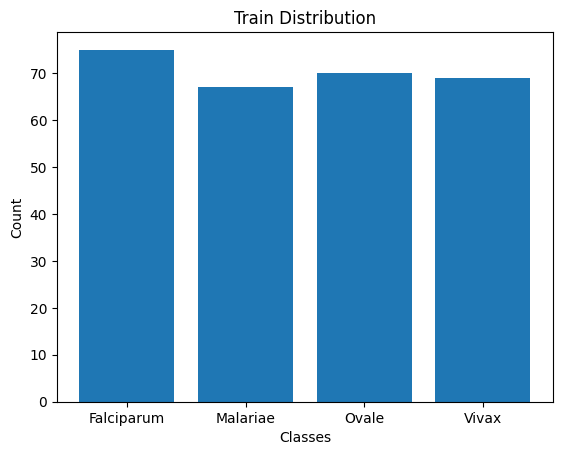

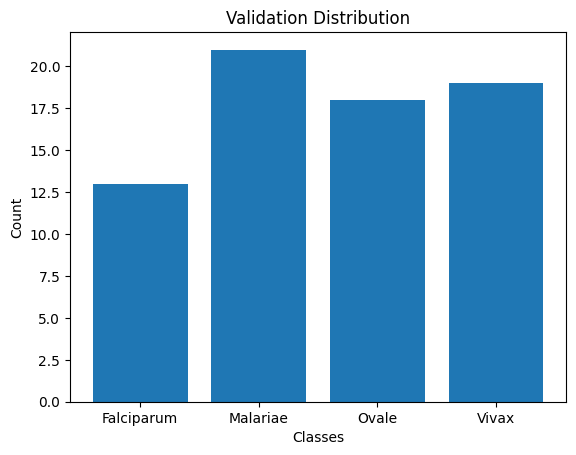

In [15]:
def plot_distribution(data, title):
    counts = Counter([x[2] for x in data])
    names = list(CLASSES.keys())
    values = [counts[i] for i in range(len(names))]

    plt.figure()
    plt.bar(names, values)
    plt.title(title)
    plt.xlabel("Classes")
    plt.ylabel("Count")
    plt.show()

plot_distribution(train_data, "Train Distribution")
plot_distribution(val_data, "Validation Distribution")

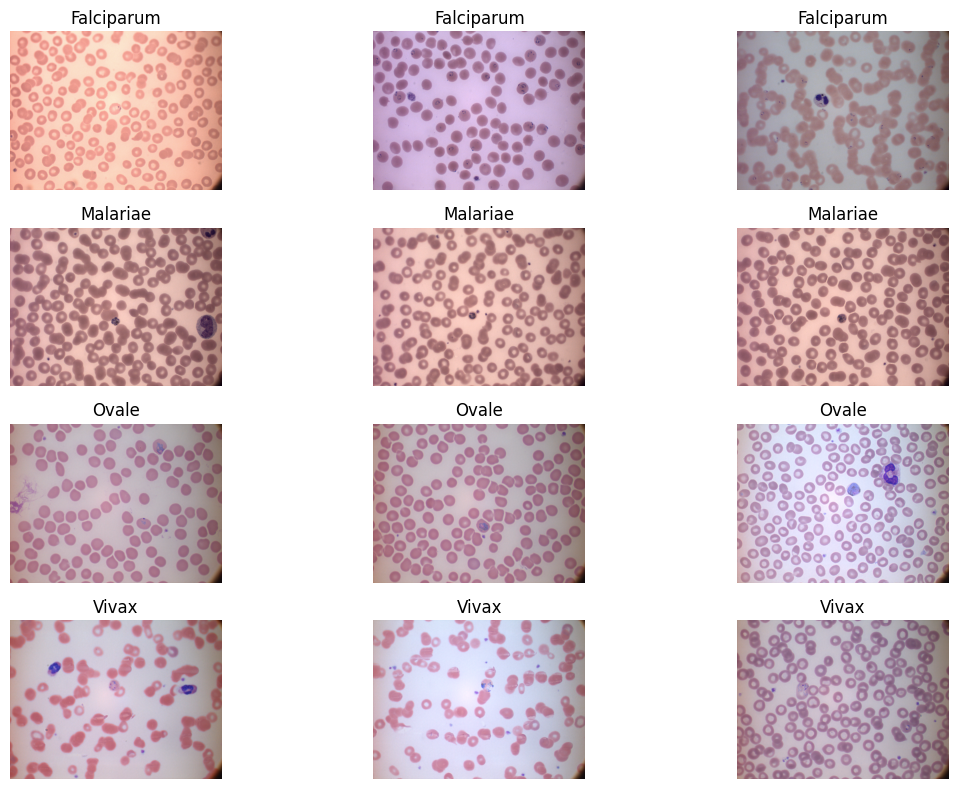

In [16]:
def show_samples(num_samples=3):
    plt.figure(figsize=(12, 8))

    for class_name, class_id in CLASSES.items():
        samples = [x for x in balanced_data if x[2] == class_id]
        samples = random.sample(samples, num_samples)

        for i, (img_path, _, _) in enumerate(samples):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(len(CLASSES), num_samples, class_id*num_samples + i + 1)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples()

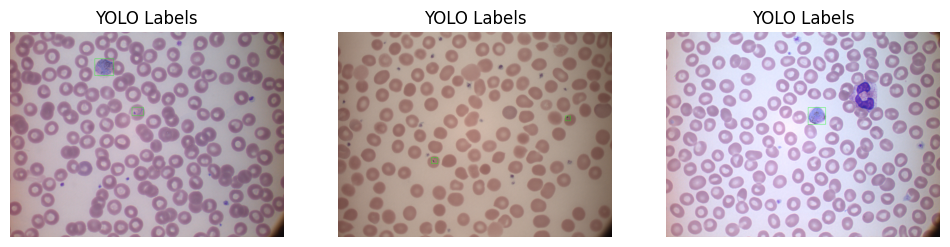

In [17]:
def show_yolo_labels(split="train", num_images=3):
    img_dir = f"{OUTPUT_PATH}/images/{split}"
    label_dir = f"{OUTPUT_PATH}/labels/{split}"

    images = random.sample(os.listdir(img_dir), num_images)

    plt.figure(figsize=(12, 5))

    for i, img_name in enumerate(images):
        img_path = os.path.join(img_dir, img_name)
        label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))

        img = cv2.imread(img_path)
        h, w = img.shape[:2]

        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f.readlines():
                    cls, x, y, bw, bh = map(float, line.split())

                    x1 = int((x - bw/2) * w)
                    y1 = int((y - bh/2) * h)
                    x2 = int((x + bw/2) * w)
                    y2 = int((y + bh/2) * h)

                    cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.title("YOLO Labels")
        plt.axis("off")

    plt.show()

show_yolo_labels()

In [12]:
yaml_content = f"""
path: {OUTPUT_PATH}

train: images/train
val: images/val

names:
  0: falciparum
  1: malariae
  2: ovale
  3: vivax
"""

with open(f"{OUTPUT_PATH}/data.yaml", "w") as f:
    f.write(yaml_content)

In [13]:
!pip install ultralytics

from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.1 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [14]:
model = YOLO("yolov8n.pt")   # start with small model

In [21]:
results = model.train(
    data="/kaggle/working/dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    lr0=0.01,
    patience=20,
    project="malaria_yolo",
    name="exp1"
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plot

In [22]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3772.2±518.9 MB/s, size: 13259.9 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 12.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.9s/it 9.5s2.8ss
                   all         71        275       0.94      0.904      0.956      0.719
            falciparum         13        202       0.91      0.901      0.916      0.544
              malariae         21         26       0.97      0.846       0.96      0.767
                 ovale         18         21      0.962          1      0.995      0.848
                 vivax         19         26      0.919      0.867      0.953      0.717
Speed: 0.7ms preprocess, 94.3ms inference, 0.0ms los

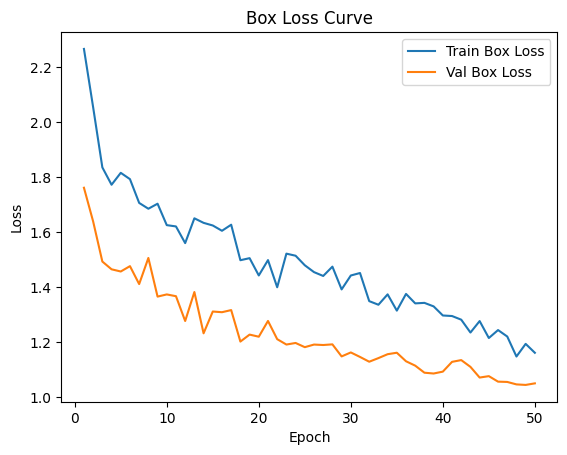

In [28]:
results_csv = "/kaggle/working/runs/detect/malaria_yolo/exp1/results.csv"
df = pd.read_csv(results_csv)

plt.figure()
plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss")
plt.legend()
plt.title("Box Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

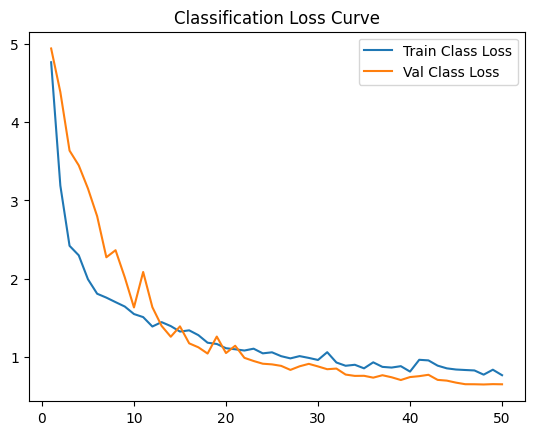

In [29]:
plt.figure()
plt.plot(df["epoch"], df["train/cls_loss"], label="Train Class Loss")
plt.plot(df["epoch"], df["val/cls_loss"], label="Val Class Loss")
plt.legend()
plt.title("Classification Loss Curve")
plt.show()

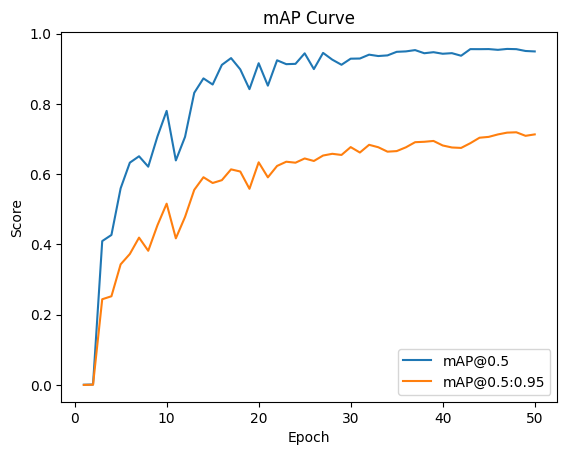

In [30]:
plt.figure()
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
plt.legend()
plt.title("mAP Curve")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.show()

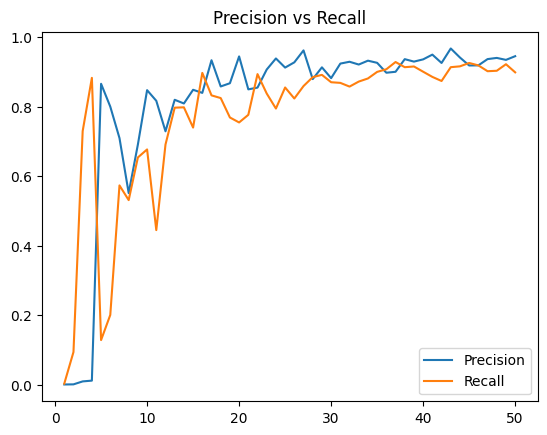

In [31]:
plt.figure()
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.legend()
plt.title("Precision vs Recall")
plt.show()

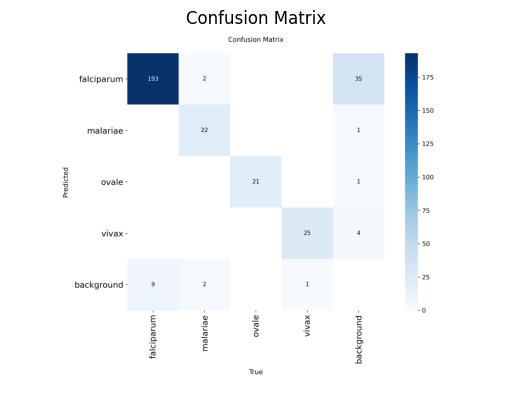

In [24]:
img = cv2.imread("runs/detect/malaria_yolo/exp1/confusion_matrix.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Confusion Matrix")
plt.axis("off")
plt.show()

In [25]:
print(metrics.box.maps)   # mAP per class

[    0.54443     0.76659     0.84778     0.71725]


In [26]:
best_model = YOLO("runs/detect/malaria_yolo/exp1/weights/best.pt")

results = best_model.predict(
    source="/kaggle/working/dataset/images/val",
    conf=0.25,
    save=True
)


image 1/71 /kaggle/working/dataset/images/val/val_0.jpg: 480x640 1 ovale, 216.0ms
image 2/71 /kaggle/working/dataset/images/val/val_1.jpg: 480x640 1 malariae, 133.2ms
image 3/71 /kaggle/working/dataset/images/val/val_10.jpg: 480x640 2 ovales, 118.1ms
image 4/71 /kaggle/working/dataset/images/val/val_11.jpg: 480x640 1 vivax, 111.6ms
image 5/71 /kaggle/working/dataset/images/val/val_12.jpg: 480x640 1 vivax, 136.6ms
image 6/71 /kaggle/working/dataset/images/val/val_13.jpg: 480x640 2 ovales, 136.4ms
image 7/71 /kaggle/working/dataset/images/val/val_14.jpg: 480x640 1 ovale, 132.4ms
image 8/71 /kaggle/working/dataset/images/val/val_15.jpg: 480x640 22 falciparums, 119.1ms
image 9/71 /kaggle/working/dataset/images/val/val_16.jpg: 480x640 2 vivaxs, 114.1ms
image 10/71 /kaggle/working/dataset/images/val/val_17.jpg: 480x640 1 malariae, 112.7ms
image 11/71 /kaggle/working/dataset/images/val/val_18.jpg: 480x640 1 malariae, 130.6ms
image 12/71 /kaggle/working/dataset/images/val/val_19.jpg: 480x640 

# Implementing with better architecture 

In [15]:
model = YOLO("yolov8s.pt")   # best balance
# OR
# model = YOLO("yolov8m.pt")   # higher accuracy (slower)

In [16]:
results = model.train(
    data="/kaggle/working/dataset/data.yaml",

    epochs=100,
    imgsz=768,            # better spatial detail (important for cells)
    batch=8,              # adjust based on memory

    lr0=0.005,            # lower LR → stable training
    lrf=0.01,

    momentum=0.937,
    weight_decay=0.0005,

    patience=30,

    optimizer="AdamW",    # better than SGD for this case

    cos_lr=True,          # cosine learning rate decay

    augment=True,         # enable augmentation

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2,

    flipud=0.5,
    fliplr=0.5,

    mosaic=1.0,
    mixup=0.2,

    close_mosaic=10,      # stop mosaic near end (important!)

    project="malaria_advanced",
    name="exp_v2"
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=30, perspecti

In [17]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4672.4±431.1 MB/s, size: 14762.6 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 33.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.6it/s 3.1s0.9ss
                   all         71        344      0.913      0.957      0.958      0.617
            falciparum         18        282      0.922      0.883      0.922      0.512
              malariae         13         15      0.907          1      0.991      0.702
                 ovale         21         23      0.941          1      0.995      0.723
                 vivax         19         24      0.883      0.945      0.924      0.531
Speed: 6.8ms preprocess, 10.9ms inferenc

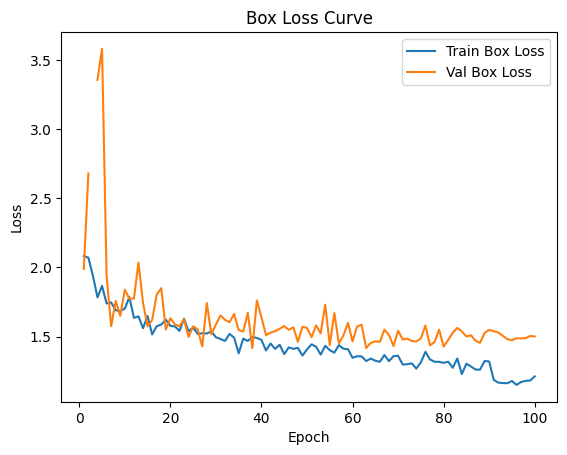

In [19]:
results_csv = "/kaggle/working/runs/detect/malaria_advanced/exp_v2/results.csv"
df = pd.read_csv(results_csv)

plt.figure()
plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss")
plt.legend()
plt.title("Box Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

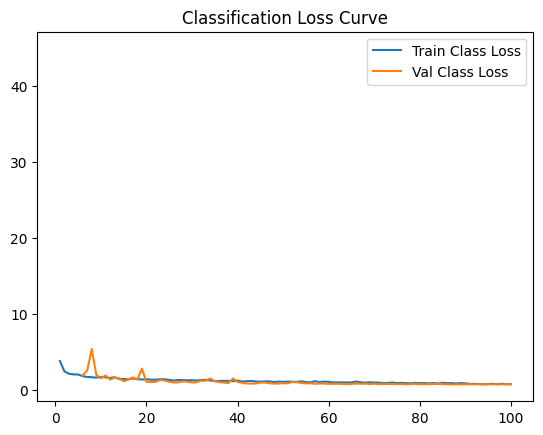

In [20]:
plt.figure()
plt.plot(df["epoch"], df["train/cls_loss"], label="Train Class Loss")
plt.plot(df["epoch"], df["val/cls_loss"], label="Val Class Loss")
plt.legend()
plt.title("Classification Loss Curve")
plt.show()

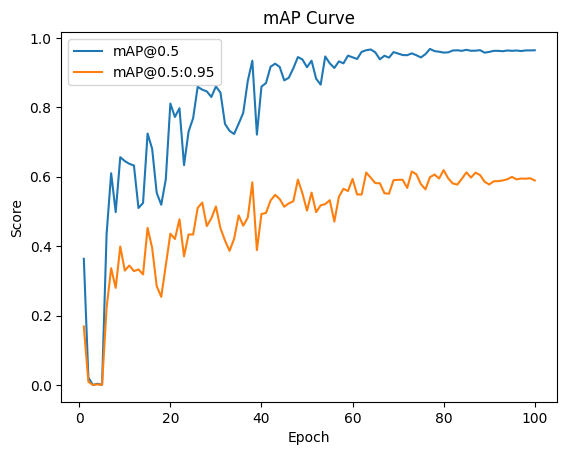

In [21]:
plt.figure()
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
plt.legend()
plt.title("mAP Curve")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.show()

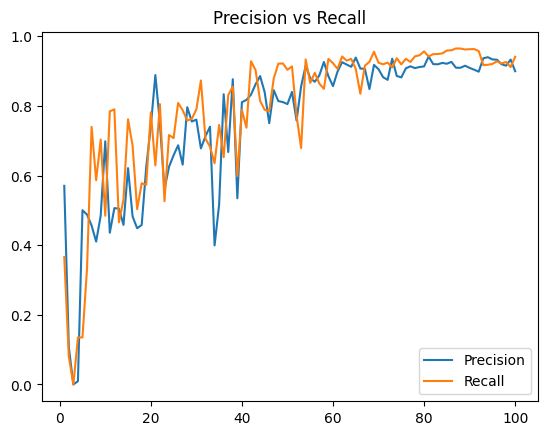

In [22]:
plt.figure()
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.legend()
plt.title("Precision vs Recall")
plt.show()

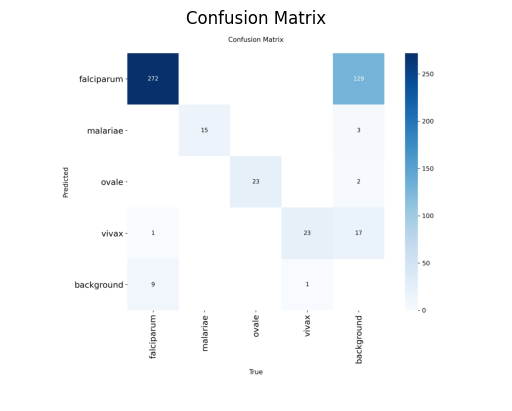

In [26]:
import cv2
img = cv2.imread("runs/detect/malaria_advanced/exp_v2/confusion_matrix.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Confusion Matrix")
plt.axis("off")
plt.show()

In [24]:
print(metrics.box.maps)   # mAP per class

[    0.51152      0.7022      0.7229      0.5306]
